# Insider Threat

### Overview

Security Operations Centers (SOCs) face a significant challenge in managing the large volume of alerts generated by modern security monitoring systems. While organizations increasingly deploy behavioral analytics, intrusion detection systems, machine learning models, and threat hunting tools, the resulting alert volume often leads to analyst fatigue and reduced investigation efficiency.

This project focuses on the problem of insider threat detection and alert prioritization. The dataset consists of security events, entities, and relationships that can be represented as a graph. Events include authentication activity, privilege operations, data access, defense evasion, and potential exfiltration behaviors. Entities represent users, hosts, files, processes, domains, databases, and network connections. Relationships connect events to the entities involved.

### Objectives

The primary goals of this analysis are:

Construct graph-based representations of security activity from the provided event, entity, and relationship data.
Develop a methodology to score and rank event graphs according to their potential risk.
Map security events to relevant MITRE ATT&CK tactics and techniques.
Use an anomaly detection technique (Isolation Forests) to detect anomalous connected components in the graph. These components should combine a large number of security incidents into smaller attack scenarios.
Determine an alert threshold that reduces analyst workload while preserving high-risk events.


### Methodology

The analysis proceeds through the following stages:

 1. Data loading and inspection
 2. Graph construction
 3. Event-to-ATT&CK mapping
 4. Anomaly scoring via. Isolation Forest
 5. Visualization of anomalous security events

The final output is a set of connected components of the graph designed to help analysts focus on the most suspicious activity while minimizing alert fatigue.

## 1. Import the required modules

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import json, sys

from collections import Counter
from datetime import datetime
from networkx.algorithms import bipartite
from sklearn.ensemble import IsolationForest

## 2. Load and inspect the data

In [2]:
with open('./security_data_assignment.json') as file:
    data = json.load(file)

print(data['metadata'])
events = pd.DataFrame(data['events'])
entities = pd.DataFrame(data['entities'])
relationships = pd.DataFrame(data['relationships'])

event_ids = events["id"]
entity_ids = entities["id"]

{'num_true_positive_scenarios': 3, 'fp_tp_ratio': 20, 'timespan': 7, 'start_time': '2026-06-03T00:01:09.718490', 'end_time': '2026-06-10T00:01:09.718490', 'num_events': 357, 'num_entities': 487, 'num_relationships': 1374}


In [3]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             357 non-null    str  
 1   type           357 non-null    str  
 2   timestamp      357 non-null    str  
 3   severity       357 non-null    int64
 4   description    357 non-null    str  
 5   alert_style    357 non-null    str  
 6   alert_message  357 non-null    str  
dtypes: int64(1), str(6)
memory usage: 19.7 KB


In [4]:
entities.info()

<class 'pandas.DataFrame'>
RangeIndex: 487 entries, 0 to 486
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          487 non-null    str   
 1   type        487 non-null    str   
 2   name        487 non-null    str   
 3   properties  487 non-null    object
dtypes: object(1), str(3)
memory usage: 15.3+ KB


In [5]:
relationships.info()

<class 'pandas.DataFrame'>
RangeIndex: 1374 entries, 0 to 1373
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   source  1374 non-null   str    
 1   target  1374 non-null   str    
 2   weight  1374 non-null   float64
 3   type    1374 non-null   str    
dtypes: float64(1), str(3)
memory usage: 43.1 KB


## 3. Create a bipartite graph

We create a bipartite graph where one of the partition is `events` and the other partitions is `entities`. The (weighted) edges are given by the `relationships` array. We also create a function which sorts the connected components in decreasing order of their sizes.

In [6]:
def create_bipartite_graph(part1, part2, edges) -> nx.Graph:
    """Load json file and return a bipartite weighted graph.

    Nodes are the `id` values from `events` and `entities`.
    Edges are created from `relationships` with the edge attribute `weight` set
    from the relationship's `weight` field. Each node gets attributes:
    - `kind`: either 'event' or 'entity'
    - `bipartite`: 0 for events, 1 for entities
    """
    G = nx.Graph()

    part1_ids = part1["id"]
    part2_ids = part2["id"]

    for nid in part1_ids:
        G.add_node(nid, bipartite=0, kind="event", color="r")
    for nid in part2_ids:
        G.add_node(nid, bipartite=1, kind="entity", color="b")

    for i, e in edges.iterrows():
        src = e["source"]
        tgt = e["target"]
        weight = e["weight"]
        rtype = e["type"]
        
        color = (0, 0, 0, weight)
        G.add_edge(src, tgt, weight=weight, type=rtype, color=color)

    return G

def connected_components_sorted(G: nx.Graph):
    """Return connected components sorted by size (descending)."""
    comps = list(nx.connected_components(G))
    comps.sort(key=len, reverse=True)
    return comps

We plot the 10 largest connected components in the graph (the brightness of edge is determined by its `weight`).

Loaded graph: 844 nodes, 1374 edges
Number of connected components: 65
10 largest components:


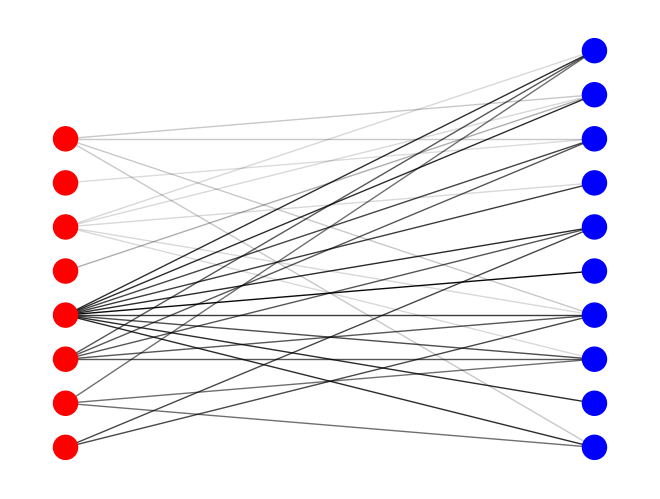

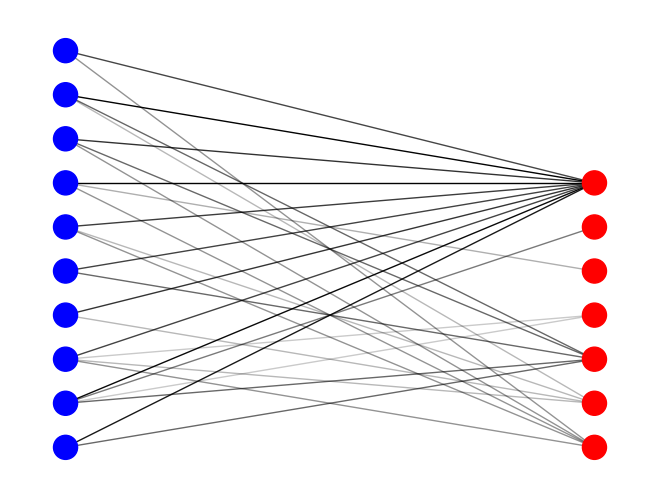

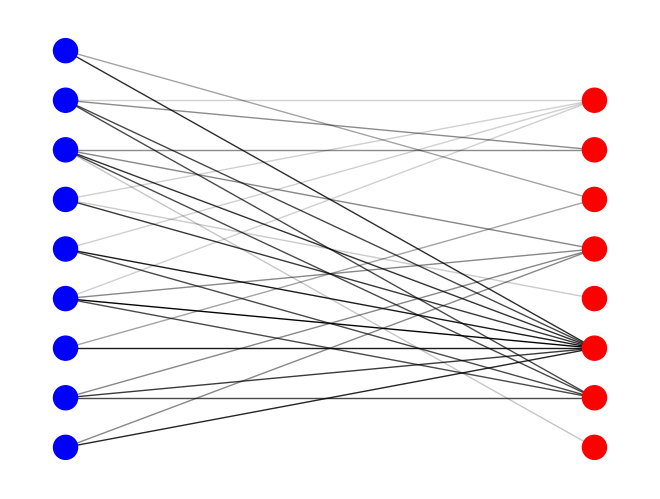

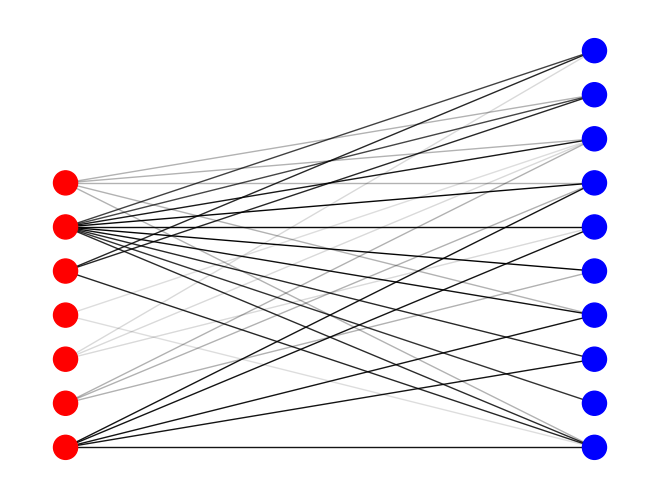

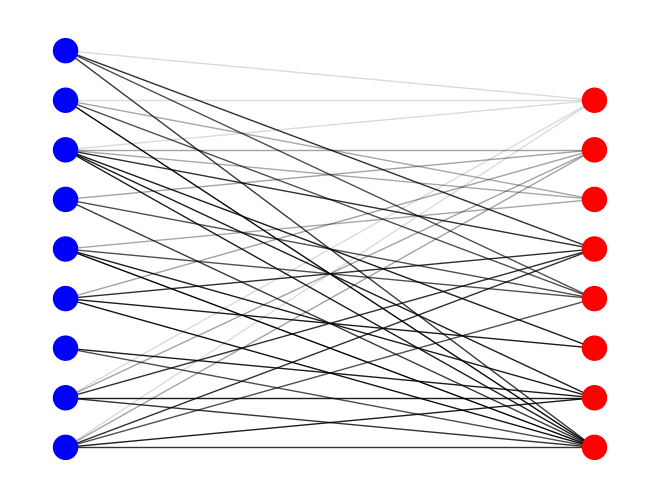

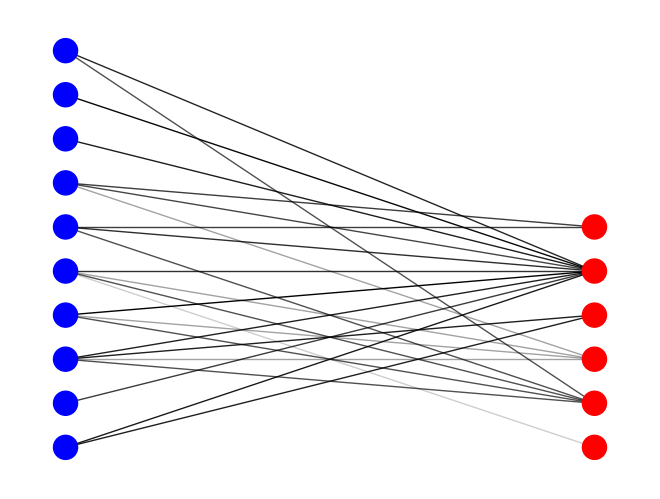

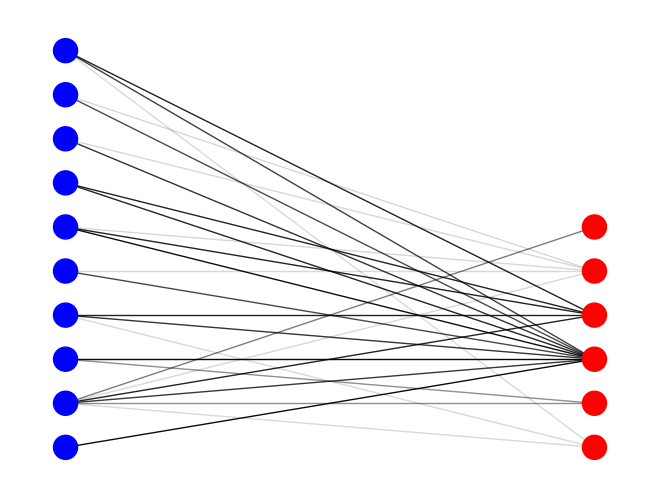

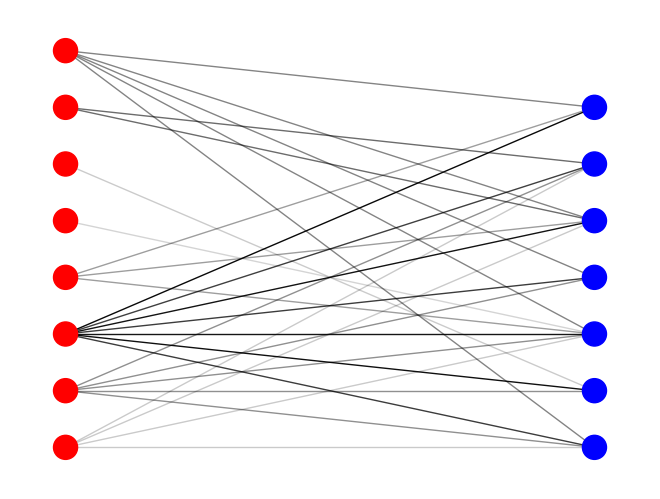

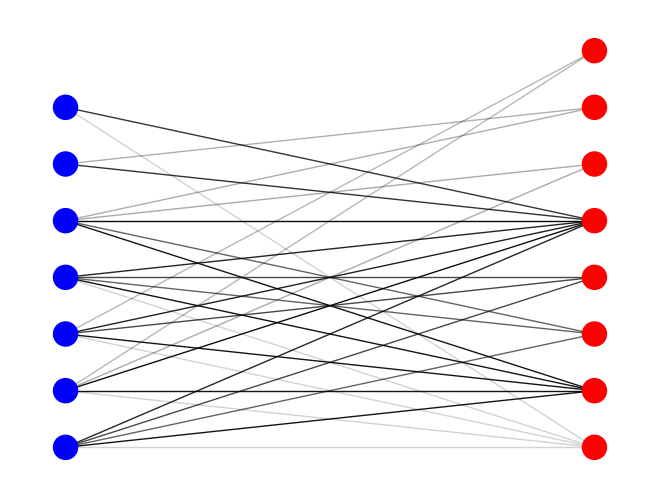

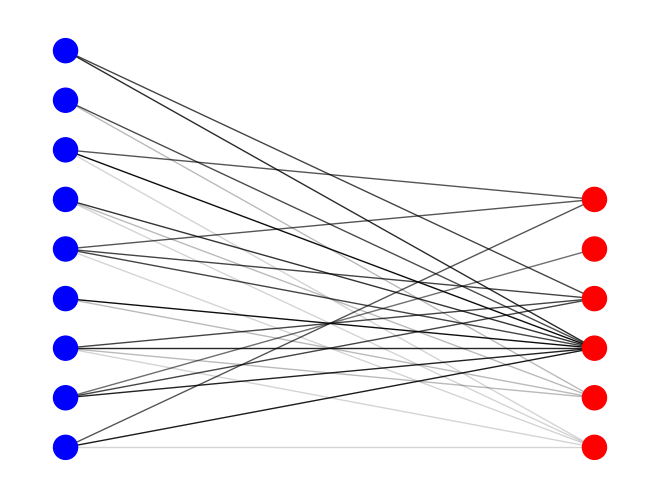

In [7]:
G = create_bipartite_graph(events, entities, relationships)
print(f"Loaded graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

comps = connected_components_sorted(G)

print(f"Number of connected components: {len(comps)}")
print("10 largest components:")

for i in range(min(10, len(comps))):
    comp = comps[i]
    plt.figure(i)

    H = nx.induced_subgraph(G, comp)
    node_colors = nx.get_node_attributes(H, 'color').values()
    edge_colors = nx.get_edge_attributes(H,'color').values()
    X, Y = bipartite.sets(H)
    pos = dict()
    pos.update( (n, (1, i)) for i, n in enumerate(X) ) # put nodes from X at x=1
    pos.update( (n, (2, i)) for i, n in enumerate(Y) ) # put nodes from Y at x=2
    nx.draw(H, pos=pos, node_color=node_colors, edge_color=edge_colors)

## 4. Set up Isolation Forest

We set up the isolation forest to detect anomalous connected components in the graph.

In [8]:
MITRE_MAP = {
    "Authentication":      ("Initial Access",      "TA0001", 0),
    "Privilege Operation": ("Privilege Escalation", "TA0004", 1),
    "Defense Evasion":     ("Defense Evasion",      "TA0005", 2),
    "Data Access":         ("Collection",           "TA0009", 3),
    "Exfiltration":        ("Exfiltration",         "TA0010", 4),
}

FEATURE_NAMES = [
    "weight_mean", "sev_mean", "sev_max",
    "n_event_types", "span_hours", "n_events", "n_entities",
]

def isolation_forest_score():
    # Build graph and find components
    event_ids = events["id"]
    entity_ids = entities["id"]

    comps = connected_components_sorted(G)

    events_by_id = {e["id"]: e for i, e in events.iterrows()}
    entities_by_id = {e["id"]: e for i, e in entities.iterrows()}
    
    have_gt = "ground_truth" in data

    if have_gt:
        gt = data.get("ground_truth", {})
        true_attack_scenarios = gt.get("attack_scenarios", [])
        scenario_ids = {}
    
        for scenario in true_attack_scenarios:
            sid = scenario["id"]
            eids = set(scenario.get("event_ids", [])).difference(set(isolated_nodes))
            enids = set(scenario.get("entity_ids", [])).difference(set(isolated_nodes))
            scenario_ids[sid] = eids.union(enids)

        print(f"True positive scenarios: {len(true_attack_scenarios)}")
        print(f"Number of true attack scenarios: {len(scenario_ids)}.")
        for sid, nodes in scenario_ids.items():
            print(f"  Scenario {sid}: {len(nodes)} nodes.")

    

        tp_event_ids = set(gt.get("true_positive_events", [])).difference(set(isolated_nodes))
        tp_entity_ids = set(gt.get("true_positive_entities", [])).difference(set(isolated_nodes))
    
    fp_tp_ratio = data.get("metadata", {}).get("fp_tp_ratio", 20)

    # Extract features per component
    results = []
    for comp in comps:
        ev_ids = {n for n in comp if G.nodes[n]["kind"] == "event"}
        en_ids = {n for n in comp if G.nodes[n]["kind"] == "entity"}

        # Skip components with no events (isolated entity nodes)
        if not ev_ids:
            continue

        evts = [events_by_id[eid] for eid in ev_ids if eid in events_by_id]
        if not evts:
            continue

        sevs = [e["severity"] for e in evts]
        times = sorted(datetime.fromisoformat(e["timestamp"]) for e in evts)
        span = (times[-1] - times[0]).total_seconds() / 3600
        weights = [G.edges[u, v].get("weight", 0)
                   for u, v in G.edges if u in comp and v in comp]
        event_types = Counter(e["type"] for e in evts)

        features = [
            np.mean(weights) if weights else 0,
            np.mean(sevs),
            max(sevs),
            len(event_types),
            span,
            len(ev_ids),
            len(en_ids),
        ]

        results.append({
            "event_ids": ev_ids,
            "entity_ids": en_ids,
            "features": features,
            "events": evts,
            "event_types": event_types,
        })

    # Run Isolation Forest

    X = np.array([r["features"] for r in results])
    n_tp_estimate = max(1, len(results) // (fp_tp_ratio + 1))
    iso = IsolationForest(
        n_estimators=200,
        contamination=n_tp_estimate / len(results),
        random_state=42,
    )
    preds = iso.fit_predict(X)
    scores = iso.decision_function(X)

    for i, r in enumerate(results):
        r["anomaly_score"] = scores[i]
        r["flagged"] = preds[i] == -1

    # Sort by anomaly score (most anomalous first)
    results.sort(key=lambda r: r["anomaly_score"])
    return results

## 5. Results

In [9]:
results = isolation_forest_score()

flagged = [r["flagged"] for r in results]

print(f"Components scored: {len(results)}")
print(f"Flagged: {sum(flagged)}")

flagged_results = [r for r in results if r["flagged"]]
flagged_results.sort(key=lambda r: r["anomaly_score"], reverse=True)


print(f"\nFLAGGED RESULTS:")
for i, r in enumerate(flagged_results):
    f = r["features"]
    print(f"  #{i+1} events={f[5]:.0f}, sev={f[1]:.1f}, "
            f"wt={f[0]:.3f}, stages={f[3]:.0f}/5, "
            f"score={r['anomaly_score']:.3f}")
    print(f"       Event IDs={r['event_ids']}")
    print(f"       Entity IDs={r['entity_ids']}")

Components scored: 65
Flagged: 3

FLAGGED RESULTS:
  #1 events=6, sev=7.7, wt=1.000, stages=5/5, score=-0.007
       Event IDs={'929e6797-24c8-4a1b-a137-7f39f28975ec', 'aed29451-3168-4d55-9c7a-176793e8cf08', '88c75527-471f-4500-b6da-309c899726aa', '3b8f9f95-7f14-4223-8bc5-4645b2e1d8cc', 'e7217606-2e6d-418b-a289-429d812d684b', '71ce08c5-424a-4aba-b0e1-855416f13570'}
       Entity IDs={'43ca77c5-bc30-41b4-a0ea-263ac324f6f7', '1267bb3e-f325-4154-a6ba-c9d9068a001d', '160e0a75-f213-46e2-8867-3fd12b8f0861', '4fbce9b1-4f60-4e1b-aa42-a7d75ae81fb5', '5766bc20-6644-4ae7-b737-34f0a83dc1b8', '8d06c4ea-0b81-453c-9f7a-23824a6e4d84', '730e779c-7775-4a18-baeb-f43a2598a44c', '65c126a4-2b8f-48f2-8d09-332cc7a934d8'}
  #2 events=5, sev=7.6, wt=1.000, stages=5/5, score=-0.022
       Event IDs={'f8ea18c3-d35b-470c-8067-5748b15e4528', '7d5cb5fd-8b6b-4a80-8a1a-da8c356b10b3', 'e838eea3-cbae-420e-a977-646fa08fcaa5', 'd524c6c0-1141-4217-bd2e-5f7398a082e3', '3e054172-7d3e-46c9-9794-a42a06c0fb90'}
       Entity ID

### Plot the anomalous components

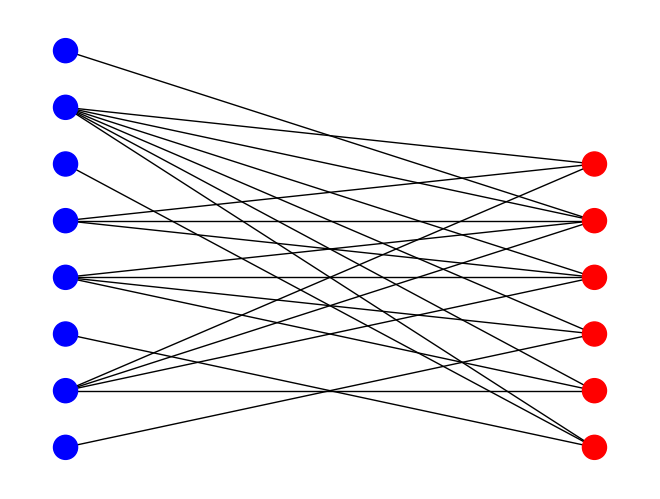

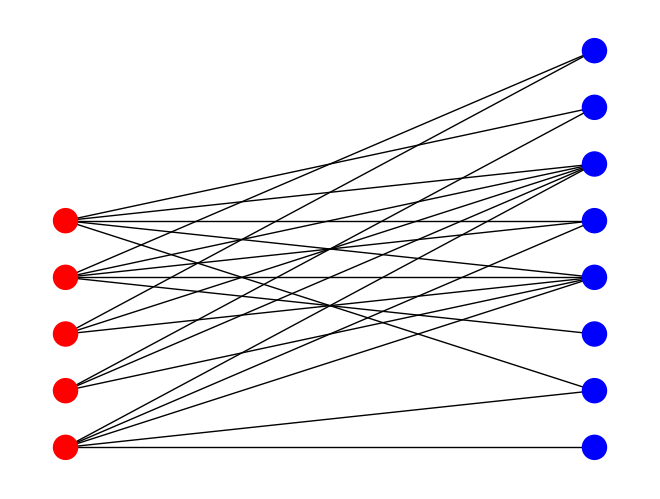

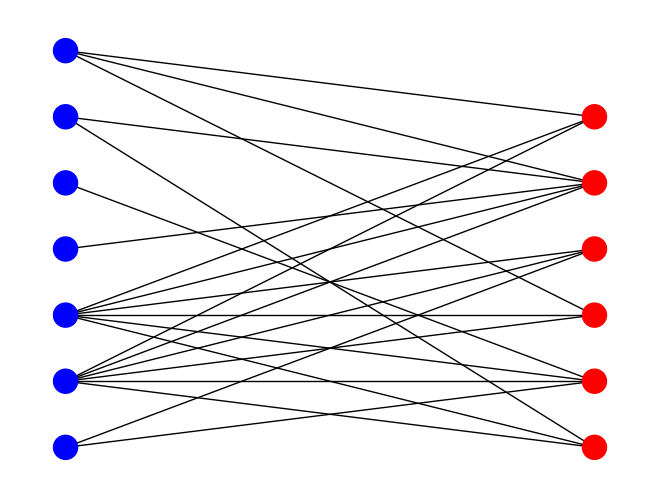

In [10]:
for i, r in enumerate(flagged_results):
    plt.figure(i)
    H = nx.induced_subgraph(G, r["event_ids"].union(r["entity_ids"]))
    node_colors = nx.get_node_attributes(H, 'color').values()
    edge_colors = nx.get_edge_attributes(H,'color').values()
    X, Y = bipartite.sets(H)
    pos = dict()
    pos.update( (n, (1, i)) for i, n in enumerate(X) ) # put nodes from X at x=1
    pos.update( (n, (2, i)) for i, n in enumerate(Y) ) # put nodes from Y at x=2
    nx.draw(H, pos=pos, node_color=node_colors, edge_color=edge_colors)